### Codes for assignment 02

### Problem 1 ::

In [4]:
from astropy.table import Table,column # imported the Table object from astropy.table method
from astropy import stats

In [5]:
t=Table.read("sfr_mass.fits",format="fits") #in Table use read method and store it in t object

In [6]:
logM=t["logM"]
logSFR=t["logSFR"]
ra=t['ra']
dec=t['dec']

Text(0, 0.5, 'logSFR')

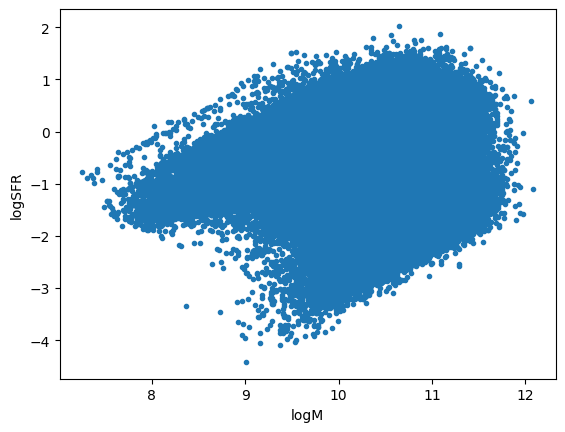

In [7]:
import matplotlib.pyplot as plt
plt.scatter(logM,logSFR,marker='.')
plt.xlabel('logM');plt.ylabel('logSFR')

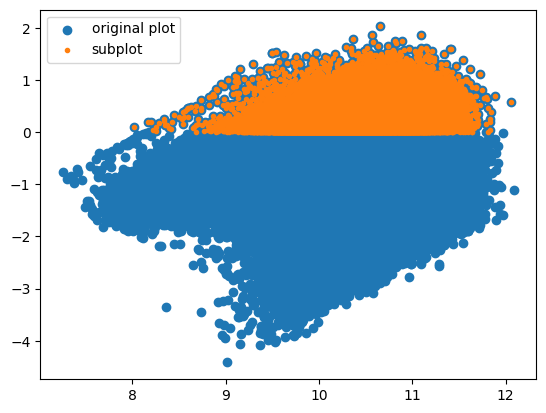

In [8]:
import numpy as np
pslogM=logM[np.where(logSFR>0)]
pslogSFR=logSFR[np.where(logSFR>0)]
plt.scatter(logM,logSFR,marker='o',label='original plot')
plt.scatter(pslogM,pslogSFR,marker='.',label='subplot')
plt.legend()
plt.show()

In [9]:
#plt.contour(x,y,counts) error

In [10]:
counts,xedges,yedges=np.histogram2d(logM,logSFR,bins=30)
xcentre=(xedges[:-1]+xedges[1:])/2
ycentre=(yedges[:-1]+yedges[1:])/2

Text(0, 0.5, 'logSFR')

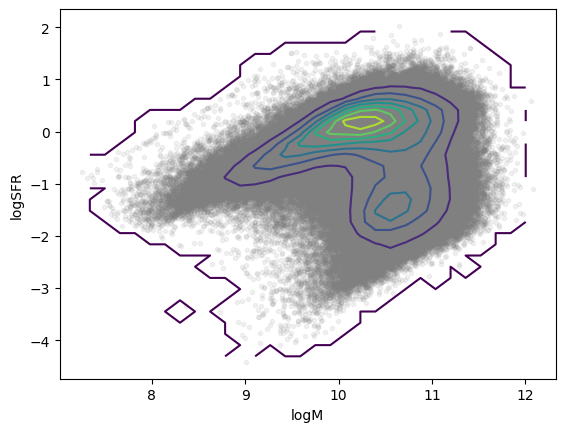

In [11]:
x,y=np.meshgrid(xcentre,ycentre)
plt.contour(x,y,counts.transpose())
plt.scatter(logM,logSFR,marker=".",alpha=0.1,color='grey')
plt.xlabel('logM')
plt.ylabel('logSFR')

### Part B

In [12]:
logsSFR=(t['logSFR']-t['logM'])

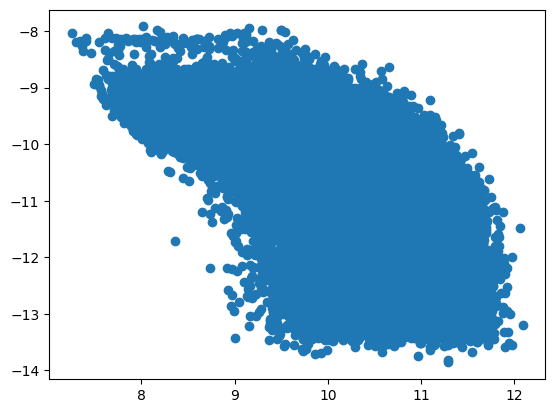

In [13]:
plt.scatter(logM,logsSFR)

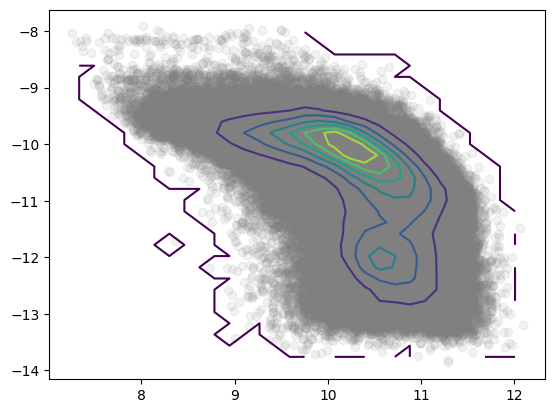

In [14]:
counts,xedges,yedges=np.histogram2d(logM,logsSFR,bins=30)
xbincenter=(xedges[:-1]+xedges[1:])/2
ybincentre=(yedges[:-1]+yedges[1:])/2
x,y=np.meshgrid(xbincenter,ybincentre)
plt.contour(x,y,counts.transpose())
plt.scatter(logM,logsSFR,alpha=0.1,color='grey')


In [15]:
star_forming=t[np.where(logsSFR>-10.8)]
passive=t[np.where(logsSFR<-11.8)]
green_valley=t[np.where(np.logical_and(logsSFR<-10.8,logsSFR>-11.8))]
print('star-forming = {} %'.format(len(star_forming)*100/len(t)))
print('passive galaxies = {} %'.format(len(passive)*100/len(t)))
print('green valley = {} %'.format(len(green_valley)*100/len(t)))

star-forming = 60.940560038458685 %
passive galaxies = 19.29677392294712 %
green valley = 19.729756761727156 %


Text(0, 0.5, 'logSFR')

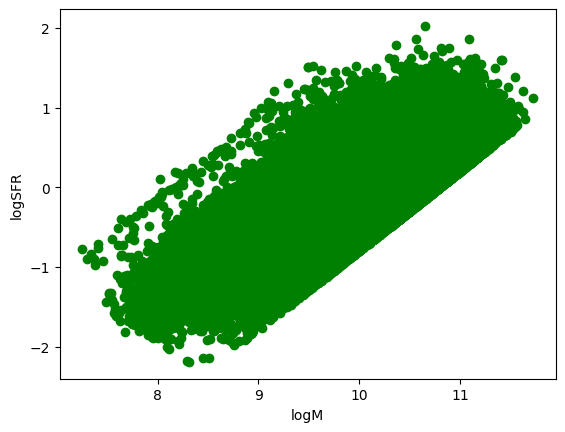

In [16]:
logM_sf=star_forming['logM']
logSFR_sf=star_forming['logSFR']
plt.scatter(logM_sf,logSFR_sf,marker='o',color='green')
plt.xlabel('logM');plt.ylabel('logSFR')

In [17]:
from scipy import stats
line=stats.linregress(logM_sf,logSFR_sf)
print(line.intercept,line.slope)

-6.1535168364291195 0.6112592443420195


Text(0, 0.5, 'logSFR')

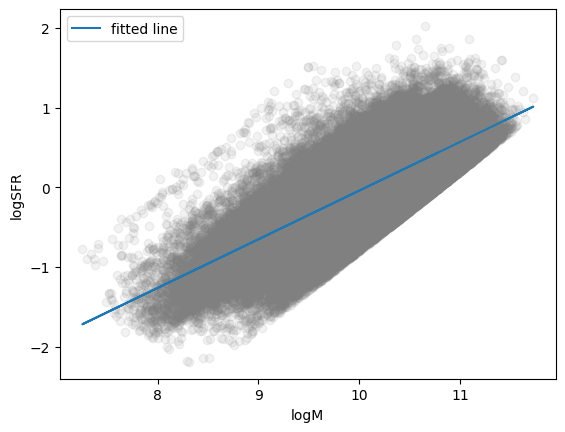

In [18]:
plt.scatter(logM_sf,logSFR_sf,marker='o',color='grey',alpha=0.1)
plt.plot(logM_sf,line.intercept+logM_sf*line.slope,label='fitted line')
plt.legend()
plt.xlabel('logM');plt.ylabel('logSFR')

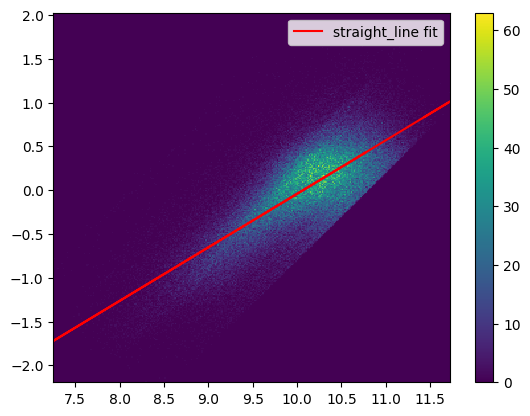

In [19]:
plt.hist2d(logM_sf,logSFR_sf,bins=300)
plt.plot(logM_sf,line.intercept+line.slope*logM_sf,label="straight_line fit",color='red')
plt.legend()
plt.colorbar()
plt.show()

In [20]:
res=logSFR_sf-(line.intercept+line.slope*logM_sf)
print(np.mean(res))
print(np.std(res))

4.884303042398648e-07
0.30629920014823525


[ 0.529 -0.283  0.064 ... -0.631  0.452  0.769]


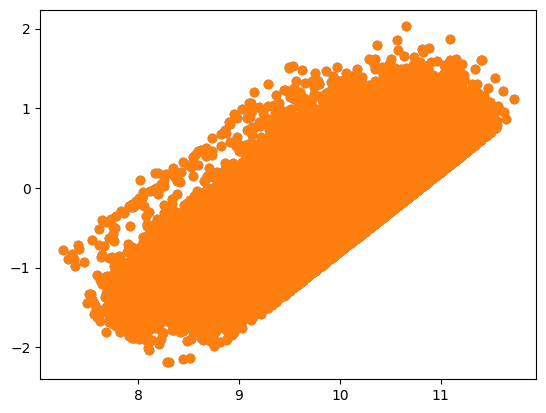

In [24]:
# we have a function in stats called as sigmaclip
from astropy import stats
clipped_data=np.copy(stats.sigma_clip(logSFR_sf,sigma=3,maxiters=2))
print(clipped_data)
plt.scatter(logM_sf,clipped_data)
plt.scatter(logM_sf,logSFR_sf)

### As a final step, add logsSFR as a new column to the existing table and save it in your favourite format

In [30]:
from astropy.table import Column
col_new=Column(data=logsSFR,name='logsSFR')
t.add_column(col_new,index=5)
t.write('sfr_mass_ssfr.fits',format='fits',overwrite=True)